# User Manual

`ethograph` allows you to visualize:

- Videos from multiple camera angles (`.mp4`, `.mov`, ...)
- Overlaid pose estimation markers (DeepLabCut, SLEAP, LightningPose via [movement](https://movement.neuroinformatics.dev))
- Audio trace and spectrogram ([audioio](https://github.com/bendalab/audioio) — `.wav`, `.mp3`, ...)
- Raw single/multi-channel electrophysiology data ([Neo](https://neo.readthedocs.io) — `.rhd`, `.abf`, `.dat`, ...)
- Raster/PSTH plots of spike-sorted units (Kilosort folders, NWB units, [pynapple](https://pynapple.org))
- Custom **feature** data (kinematics, behavioural time-series, firing rates, latent variables, model outputs, ...)

Feature data can be loaded via three backends:

| Backend | Object | File format |
|---------|--------|-------------|
| **xarray** | {class}`xarray.Dataset` / {class}`~ethograph.io.trialtree.TrialTree` | `.nc` |
| **Pynapple** | {class}`~pynapple.Tsd` / {class}`~pynapple.TsdFrame` | `.npz` or folder |
| **NWB** | `.nwb` (loaded via {mod}`pynapple`) | `.nwb` |

Unlike a plain numpy array, all three formats carry explicit timestamps with each value.
This allows `ethograph` to automatically align data of different sampling rates and
modalities (video, audio & electrophysiology).

## Feature dimension filtering

We'll use real pose data from the Moll et al., 2025 crow tool-use dataset.
{func}`eto.sample_data() <ethograph.sample_data>` downloads one trial (~14 MB on first call) and returns
an {class}`xarray.Dataset` with position, velocity, speed, and acceleration for 3
keypoints tracked in 3D.

In [1]:
import ethograph as eto

ds = eto.sample_data()
print(ds)

<xarray.DatasetView> Size: 648kB
Dimensions:               (time: 1169, space: 3, keypoints: 3, individuals: 1,
                           s3d_dims: 20, RGB: 3)
Coordinates:
  * time                  (time) float64 9kB 0.0 0.005 0.01 ... 5.83 5.835 5.84
  * space                 (space) <U1 12B 'x' 'y' 'z'
  * keypoints             (keypoints) <U8 96B 'beakTip' 'stickTip' 'pellet'
  * individuals           (individuals) <U5 20B 'Crow1'
Dimensions without coordinates: s3d_dims, RGB
Data variables: (12/14)
    position              (time, space, keypoints, individuals) float64 84kB ...
    confidence            (time, keypoints, individuals) float32 14kB ...
    velocity              (time, space, keypoints, individuals) float64 84kB ...
    speed                 (time, keypoints, individuals) float64 28kB ...
    acceleration          (time, space, keypoints, individuals) float64 84kB ...
    pellet_beakTip_dist   (time) float64 9kB ...
    ...                    ...
    disp_stickTip_d

Notice the dimensions:

| Feature | Dimensions |
|---------|------------|
| `position` | `(time, space, keypoints, individuals)` |
| `velocity` | `(time, space, keypoints, individuals)` |
| `speed` | `(time, keypoints, individuals)` |

`speed` has no `space` dimension because the spatial components were collapsed
during computation (norm over x, y, z). This is fine — the GUI handles mismatched
dimensions via `sel_valid`.

### {func}`~ethograph.sel_valid` — select across dimensions that may not exist

{func}`~ethograph.sel_valid` filters a selection dict to only the dimensions present on the
target variable. Dimensions that don't exist are silently ignored.

In [2]:
selection = {"keypoints": "beakTip", "space": "x", "individuals": "Crow1"}

# For position: all three selection keys apply
pos_data, used = eto.sel_valid(ds["position"], selection)
print(f"position: applied {used}, result shape {pos_data.shape}")

# For speed: 'space' is silently dropped (speed has no space dim)
spd_data, used = eto.sel_valid(ds["speed"], selection)
print(f"speed:    applied {used}, result shape {spd_data.shape}")

position: applied {'keypoints': 'beakTip', 'space': 'x', 'individuals': 'Crow1'}, result shape (1169,)
speed:    applied {'keypoints': 'beakTip', 'individuals': 'Crow1'}, result shape (1169,)


In the GUI, each dimension gets a **combo box** dropdown. The **All** checkbox
next to each combo shows all values of that dimension overlaid.

### x-position, x-velocity, and speed for the beak tip

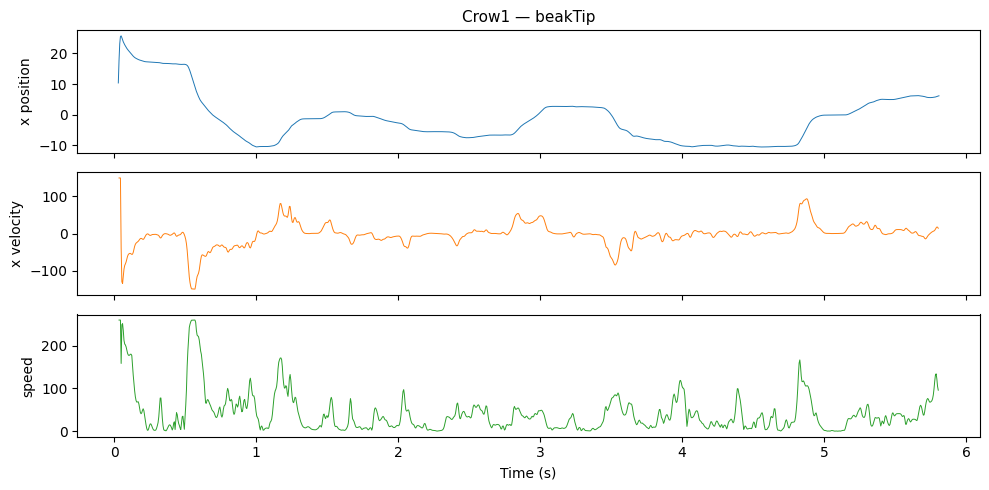

In [3]:
import matplotlib.pyplot as plt
import numpy as np

time_s = ds.time.values
sel = {"keypoints": "beakTip", "individuals": "Crow1"}

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)

# x-position (select space before sel_valid)
pos_x, _ = eto.sel_valid(ds["position"].sel(space="x"), sel)
axes[0].plot(time_s, pos_x, color="#1f77b4", linewidth=0.7)
axes[0].set_ylabel("x position")
axes[0].set_title("Crow1 \u2014 beakTip", fontsize=11)

# x-velocity
vel_x, _ = eto.sel_valid(ds["velocity"].sel(space="x"), sel)
axes[1].plot(time_s, vel_x, color="#ff7f0e", linewidth=0.7)
axes[1].set_ylabel("x velocity")

# speed (no space dimension \u2014 sel_valid drops 'space' silently)
spd_sel, _ = eto.sel_valid(ds["speed"], sel)
axes[2].plot(time_s, spd_sel, color="#2ca02c", linewidth=0.7)
axes[2].set_ylabel("speed")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

`position` and `velocity` have a `space` dimension (you select x, y, or z).
`speed` does not — it's a scalar derived from the velocity norm.
When you select `space=x` in the GUI, it applies to `position` and `velocity`
but is silently ignored for `speed`. This is the key principle behind {func}`~ethograph.sel_valid`.

### Comparing across keypoints

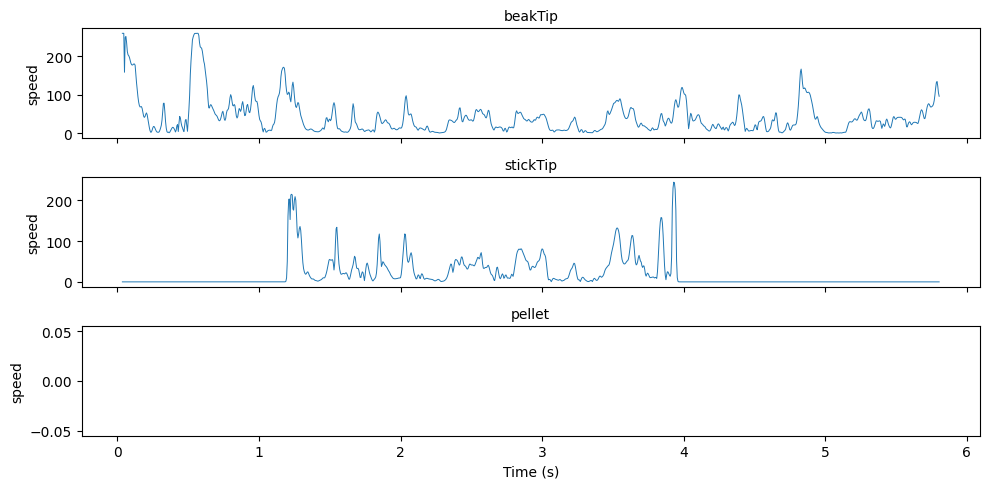

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)

for i, kp in enumerate(ds.keypoints.values):
    spd_kp, _ = eto.sel_valid(ds["speed"], {"keypoints": kp, "individuals": "Crow1"})
    axes[i].plot(time_s, spd_kp, linewidth=0.7)
    axes[i].set_ylabel("speed")
    axes[i].set_title(kp, fontsize=10)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

The beak tip shows fast, sharp movements (tool insertion), while the pellet
is mostly stationary until the crow snaps it.

### 3D trajectory

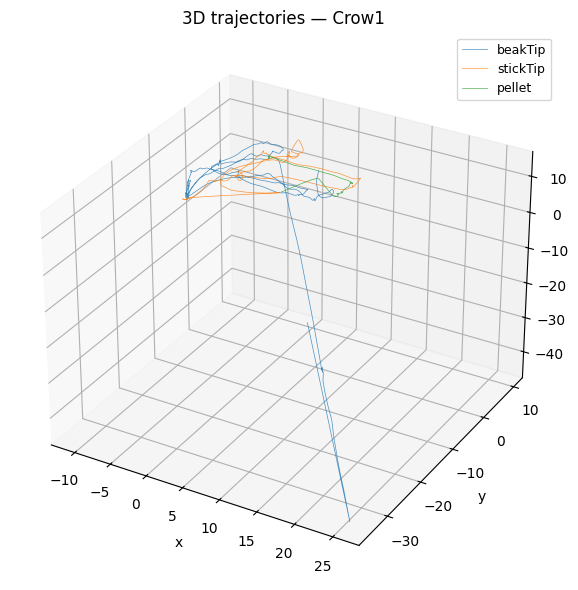

In [5]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

for kp in ds.keypoints.values:
    pos, _ = eto.sel_valid(ds["position"], {"keypoints": kp, "individuals": "Crow1"})
    # pos is (n_time, 3) — columns are x, y, z
    ax.plot(pos[:, 0], pos[:, 1], pos[:, 2], linewidth=0.5, label=kp, alpha=0.8)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(fontsize=9)
ax.set_title("3D trajectories \u2014 Crow1")
plt.tight_layout()
plt.show()

## Building a TrialTree

A single {class}`xarray.Dataset` holds one trial. A {class}`~ethograph.io.trialtree.TrialTree` wraps multiple
trials into one object:

In [6]:
# Wrap as a TrialTree (here just one trial for demo)
dt = eto.from_datasets([ds])

print(f"Trials: {dt.trials}")
print(f"Trial at index 0: {dt.itrial(0).attrs['trial']}")
print(f"Features: {list(dt.trial(dt.trials[0]).data_vars)[:5]}...")

Trials: [115]
Trial at index 0: 115
Features: ['position', 'confidence', 'velocity', 'speed', 'acceleration']...


### Iterating and transforming

In [7]:
# Iterate over trials
for trial_id, trial_ds in dt.trial_items():
    mean_speed = float(trial_ds["speed"].mean())
    print(f"Trial {trial_id}: mean speed = {mean_speed:.3f}")

Trial 115: mean speed = 30.415


### Smoothed vs raw speed

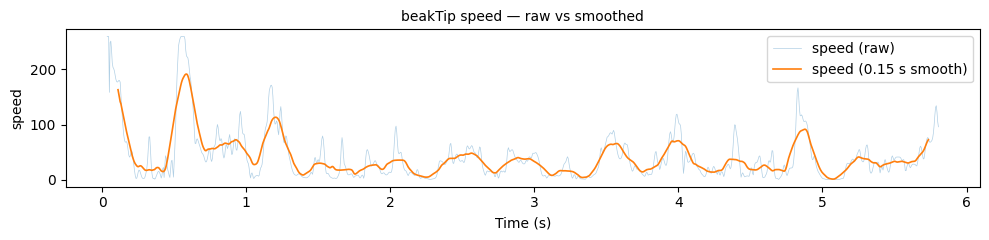

In [8]:
trial_ds = dt.itrial(0)
sel = {"keypoints": "beakTip", "individuals": "Crow1"}

raw, _ = eto.sel_valid(trial_ds["speed"], sel)
# Smooth with a 0.15 s window (30 frames at 200 fps)
smooth = trial_ds["speed"].rolling(time=30, center=True).mean()
smooth_sel, _ = eto.sel_valid(smooth, sel)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(time_s, raw, alpha=0.35, linewidth=0.5, label="speed (raw)")
ax.plot(time_s, smooth_sel, linewidth=1.2, label="speed (0.15 s smooth)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("speed")
ax.legend()
ax.set_title("beakTip speed \u2014 raw vs smoothed", fontsize=10)
plt.tight_layout()
plt.show()

## Data requirements summary

| | xarray | Pynapple | NWB |
|--|--------|----------|-----|
| **File format** | `.nc` via {class}`~ethograph.io.trialtree.TrialTree` | `.npz` or folder | `.nwb` |
| **Required attrs** | `trial`, `fps` | *(none)* | *(NWB standard)* |
| **Features** | Any `data_var` with a time dim | Any {class}`~pynapple.Tsd` / {class}`~pynapple.TsdFrame` | {class}`~pynwb.TimeSeries` in processing |
| **Individuals** | `coords["individuals"]` | Separate objects | One subject per file |
| **Trials** | One `Dataset` per trial | {class}`~pynapple.IntervalSet` | `nwb.trials` table |

See [Data Format Requirements](data_requirements.md) for full specifications
across all three backends.

## Operations across backends

| Operation | xarray / TrialTree | Pynapple | NWB |
|-----------|-------------------|----------|-----|
| **Load** | {func}`~ethograph.open` | {func}`~ethograph.load_nap_data` | {func}`~ethograph.load_nap_data` |
| **Restrict** | {meth}`~xarray.Dataset.sel` | {meth}`~pynapple.Tsd.restrict` | Via {mod}`pynapple` |
| **Select dims** | {func}`~ethograph.sel_valid` | Column indexing on {class}`~pynapple.TsdFrame` | Via {mod}`pynapple` |
| **Build** | {func}`~ethograph.from_datasets` | {func}`~pynapple.save_file` | {class}`~pynwb.NWBHDF5IO` |
| **Alignment** | `.ethograph/alignment.nwb` | `.ethograph/alignment.nwb` | In source `.nwb` |
| **Iterate trials** | {meth}`~ethograph.io.trialtree.TrialTree.trial_items` | {meth}`~pynapple.Tsd.restrict` | Via {mod}`pynapple` |